<a href="https://colab.research.google.com/github/Suvanga/ML_DL/blob/main/CNN_from_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [372]:
import torch
from torch import nn

import pandas as pd
import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
from timeit import default_timer as timer
from torch.utils.data import DataLoader
import requests
from pathlib import Path

import requests
from pathlib import Path

import matplotlib.pyplot as plt

In [373]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functoins already exist")
else:
  requests = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/refs/heads/main/helper_functions.py")
  with open("helper_functions.py","wb")as f: ##this sets the permissipon of the file to write binary functions here in the file
    f.write(requests.content)  #now we write the contents inside the helper function.py file we just created

from helper_functions import accuracy_fn




helper_functoins already exist


In [374]:
#device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [375]:
##Training Data
train_data = datasets.FashionMNIST(
  root = "data", #Where to download the data to ?
  train = True, #get training data
  download = True, #download data if it doesn't exist
  transform=ToTensor(), #convert to tensor
  target_transform=None
)

#Testing Data
test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = ToTensor(),
    target_transform=None
)

##See the first training example
image , label = train_data[0]
# image , label

class_names = train_data.classes
class_names_idx = train_data.class_to_idx
print (f"\n{class_names_idx}")


{'T-shirt/top': 0, 'Trouser': 1, 'Pullover': 2, 'Dress': 3, 'Coat': 4, 'Sandal': 5, 'Shirt': 6, 'Sneaker': 7, 'Bag': 8, 'Ankle boot': 9}


In [376]:
BATCH_SIZE = 32

train_dataloader = DataLoader(dataset = train_data,
                              batch_size = BATCH_SIZE,
                              shuffle = True)
test_dataloader = DataLoader(dataset = test_data,
                              batch_size = BATCH_SIZE,
                              shuffle = False)


from PIL.Image import ImageTransformHandler
##CNN
* It is known for finding pattern in visual data
* Input layer -> Just like any neural network
* Convolution Layer: learns the most important features from the target ImageTransformHandler
* https://poloclub.github.io/cnn-explainer/

In [377]:
from torch.nn.modules.conv import Conv2d
class FashionMNISTModelV2(nn.Module):
  """
  Model architechture that replicates the tinyVGG
  Model from CNN explainer website is being implemented
  """
  def __init__(self, input_shape:int, hidden_units:int, output_shape: int):
    super() .__init__()
    self.conv_block_1 = nn.Sequential(
        #create a conv layer https://pytorch.org/docs/stable/generated/torch.nn.Conv2d.html
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding = 1
    ),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride =1,
                  padding =1
        ),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size =2,)
    )

    self.conv_block_2 =nn.Sequential(nn.Conv2d(
                                  in_channels = hidden_units,
                                  out_channels = hidden_units,
                                  kernel_size = 3,
                                  stride =1,
                                  padding =1),
        nn.ReLU(),
        nn.Conv2d(in_channels = hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride =1,
                  padding =1),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size =2)
    )
    self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features = hidden_units*7*7, # Corrected: Calculate based on image dimensions after conv/pool layers
                      out_features = output_shape)
        )

  def forward(self,x:torch.Tensor):
    x =  self.conv_block_1(x)
    # print(f"Output Shape of Comnv block1{x.shape}")
    x = self.conv_block_2(x)
    # print(f"Output Shape of conv block2 {x.shape}")
    x = self.classifier(x)
    # print(f"Output shape of the classifier {x.shape}")
    return x

In [378]:
rand_image_tensor = torch.randn(size =(1,28,28)).unsqueeze(0).to(device)
rand_image_tensor.shape

torch.Size([1, 1, 28, 28])

In [379]:
model_2(rand_image_tensor)

tensor([[ 2.6168,  0.9194, -0.7419,  0.4622, -1.1205,  1.8743, -1.7151, -1.7199,
          3.3426, -4.7627]], grad_fn=<AddmmBackward0>)

#7.1 stepping through `nn.conv2d`

In [380]:
#creating a batch of images
images = torch.randn(size = (32,3,64,64))
test_image = images[0]

print(f"Image batch shape : {images.shape}")
print(f"Single image shape : {test_image.shape}")
print(f"test image \n {test_image}")


Image batch shape : torch.Size([32, 3, 64, 64])
Single image shape : torch.Size([3, 64, 64])
test image 
 tensor([[[-0.5218,  0.8302, -0.0510,  ..., -0.1000, -0.5615, -0.5949],
         [-0.8810,  0.3484,  0.6930,  ...,  1.7930,  0.8703, -1.0553],
         [ 0.8917,  0.7002,  0.4082,  ...,  0.2977, -1.0284,  0.4044],
         ...,
         [ 0.1345, -0.2990, -1.5144,  ...,  0.1062, -1.0277, -0.9919],
         [-0.7258, -1.3324,  1.3753,  ...,  0.2383, -0.1970,  1.0387],
         [-2.4338,  0.4683, -0.1544,  ..., -0.7797, -1.6657,  0.3285]],

        [[-0.8700,  0.7166,  0.7405,  ..., -0.1364,  0.4567,  1.1066],
         [ 0.4604,  0.9161,  0.8900,  ..., -0.6646, -1.0612,  2.0423],
         [-0.3331,  1.9079, -0.2092,  ..., -0.2419,  1.4872,  0.6042],
         ...,
         [ 0.6370,  0.4737, -1.3896,  ..., -1.6284, -0.7042, -2.9895],
         [-0.5418,  0.0475, -0.4170,  ..., -1.5815,  0.1947,  1.3355],
         [ 0.6254, -0.4938, -0.2869,  ..., -0.5912,  1.2889, -1.5123]],

        [[

In [381]:
# code for testing conv_layer for block cell 12 and 13
torch.manual_seed(42)

conv_layer = nn.Conv2d(in_channels = 3,
                       out_channels=10,
                       kernel_size=(3,3),
                       stride =1,
                       padding =0)
conv_output = conv_layer(test_image)
conv_output.shape

torch.Size([10, 62, 62])

In [382]:
#going through conv2d layer
#printing out original image shape
print(f"Image batch shape : {images.shape}")
print(f"Single image shape : {test_image.shape}")

#creating a sample nn.MaxPool2d layer
max_pool_layer = nn.MaxPool2d(kernel_size =2)

#pass the conv later first
test_image_through_conv =conv_layer(test_image.unsqueeze(dim=0))
print(f"Shape after going through conv layer {test_image_through_conv.shape}")

#Pass the data through max pool layer
max_pool_output = max_pool_layer(test_image_through_conv)
print(f"Shape after going through max pool layer {max_pool_output.shape}")

Image batch shape : torch.Size([32, 3, 64, 64])
Single image shape : torch.Size([3, 64, 64])
Shape after going through conv layer torch.Size([1, 10, 62, 62])
Shape after going through max pool layer torch.Size([1, 10, 31, 31])


In [383]:
#going through max pool layer
torch.manual_seed(42)

random_tensor = torch.randn(size =(1,1,2,2))
random_tensor
print(f"random tensor: {random_tensor}")
print(f"random tensor shape: {random_tensor.shape}\n")

#creating a max pool layer
max_pool_layer = nn.MaxPool2d(kernel_size =2)
max_pool_tensor = max_pool_layer(random_tensor)

#printing the new max pooled tnesor
print(f" max_pool_tensor{max_pool_tensor}")
print("Max pool tensor shape",max_pool_tensor.shape)



random tensor: tensor([[[[0.3367, 0.1288],
          [0.2345, 0.2303]]]])
random tensor shape: torch.Size([1, 1, 2, 2])

 max_pool_tensortensor([[[[0.3367]]]])
Max pool tensor shape torch.Size([1, 1, 1, 1])


##Trainign and testing our first CNN
* Setup loss and optimizer


In [384]:
#instantiating a model
torch.manual_seed(42)
model_2 = FashionMNISTModelV2(input_shape = 1,
                              hidden_units = 10,
                              output_shape = len(class_names)).to(device)

# Setting up the optimizer *after* model is instantiated
optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)
loss_fn = nn.CrossEntropyLoss()

In [385]:

import torch
from tqdm.auto import tqdm

def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device):
    train_loss, train_acc = 0, 0
    model.train()
    for batch, (X, y) in enumerate(data_loader):
        X, y = X.to(device), y.to(device)
        y_pred = model(X)
        loss = loss_fn(y_pred, y)
        train_loss += loss
        train_acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    train_loss = train_loss / len(data_loader) # Changed from /= to =
    train_acc /= len(data_loader)
    print(f"Train loss: {train_loss:.5f} | Train acc: {train_acc:.2f}%")

def test_step(model: torch.nn.Module,
              data_loader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              device: torch.device):
    test_loss, test_acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            test_pred = model(X)
            test_loss += loss_fn(test_pred, y)
            test_acc += accuracy_fn(y_true=y, y_pred=test_pred.argmax(dim=1))
    test_loss = test_loss / len(data_loader) # Changed from /= to =
    test_acc /= len(data_loader)
    print(f"Test loss: {test_loss:.5f} | Test acc: {test_acc:.2f}%")

def eval_model(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               accuracy_fn,
               device: torch.device):
    loss, acc = 0, 0
    model.eval()
    with torch.inference_mode():
        for X, y in tqdm(data_loader):
            X, y = X.to(device), y.to(device)
            y_pred = model(X)
            loss += loss_fn(y_pred, y)
            acc += accuracy_fn(y_true=y, y_pred=y_pred.argmax(dim=1))
        loss = loss / len(data_loader) # Changed from /= to =
        acc /= len(data_loader)
    return {"model_name": model.__class__.__name__,
            "model_loss": loss.item(),
            "model_acc": acc}


In [386]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
from tqdm.auto import tqdm
#Measure
train_time_start_model_2 = timer()

#Train and test the model
epochs = 3

for epoch in tqdm(range(epochs)):
  print(f"Epoch: {epoch}\n---------")
  train_step(model = model_2,
             data_loader = train_dataloader,
             optimizer = optimizer,
             loss_fn = loss_fn,
             accuracy_fn = accuracy_fn,
             device = device)

  test_step(model = model_2,
            data_loader = test_dataloader,
            loss_fn = loss_fn,
            accuracy_fn = accuracy_fn, # Added accuracy_fn
            device = device)

train_time_end_model_2 = timer()
total_train_time_model_2 = train_time_end_model_2 - train_time_start_model_2
print(f"Total training time: {total_train_time_model_2:.3f} seconds")

  0%|          | 0/3 [00:00<?, ?it/s]

Epoch: 0
---------
Train loss: 0.59518 | Train acc: 78.38%
Test loss: 0.39500 | Test acc: 85.99%
Epoch: 1
---------
Train loss: 0.36536 | Train acc: 86.90%
Test loss: 0.35244 | Test acc: 86.91%
Epoch: 2
---------
Train loss: 0.32588 | Train acc: 88.13%
Test loss: 0.32719 | Test acc: 88.07%
Total training time: 182.177 seconds


In [387]:
model_2_results = eval_model(model = model_2,
                             data_loader = test_dataloader,
                             loss_fn = loss_fn,
                             accuracy_fn = accuracy_fn,
                             device = device)
model_2_results

  0%|          | 0/313 [00:00<?, ?it/s]

{'model_name': 'FashionMNISTModelV2',
 'model_loss': 0.32718968391418457,
 'model_acc': 88.06908945686901}

In [388]:
# Manually inputting results from your other files
model_0_results = {
    "model_name": "FashionMNISTModelV0",
    "model_loss": 0.476,
    "model_acc": 83.42,
    "training_time": 45.12
}

model_1_results = {
    "model_name": "FashionMNISTModelV1",
    "model_loss": 0.685,
    "model_acc": 75.01,
    "training_time": 150.34
}

# Add training time to your current model results
model_2_results["training_time"] = 182.089


In [389]:
import pandas as pd

# Combine all results into a list
all_model_results = [model_0_results, model_1_results, model_2_results]

# Create DataFrame
compare_df = pd.DataFrame(all_model_results)

# Calculate accuracy per second to see efficiency
compare_df["acc_per_second"] = compare_df["model_acc"] / compare_df["training_time"]

print(compare_df)

            model_name  model_loss  model_acc  training_time  acc_per_second
0  FashionMNISTModelV0     0.47600  83.420000         45.120        1.848848
1  FashionMNISTModelV1     0.68500  75.010000        150.340        0.498936
2  FashionMNISTModelV2     0.32719  88.069089        182.089        0.483660


Text(0, 0.5, 'model')

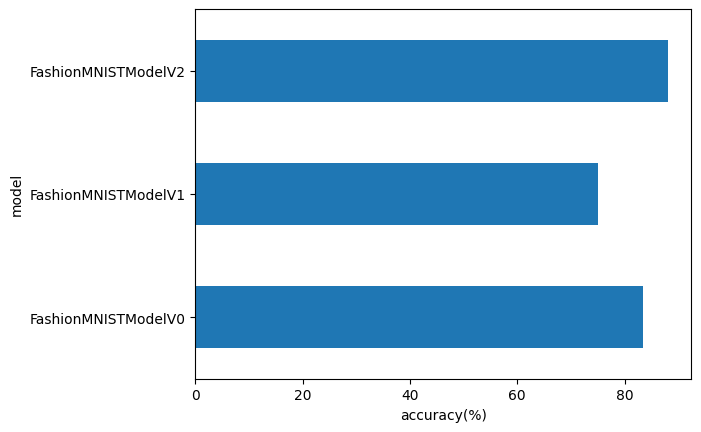

In [390]:
compare_df.set_index("model_name")["model_acc"].plot(kind="barh")
plt.xlabel("accuracy(%)")
plt.ylabel("model")

In [392]:
def make_predictions(model:torch.nn.Module,
                     data:list,
                     device: torch.device =device):
  pred_probs =[]
  model.to(device)
  model.eval()

  with torch.inference_mode():
    for sample in data :
      sample = torch.unsqueeze(sample, dim =0).to(device)
      pred_logits = model(sample)

      pred_probs = torch.softmax(pred_logits.squeeze(), dim =0)

      pred_probs.append(pred_probs.cpu().detach().numpy())

  return pred_probs

In [396]:
import random
random.seed(42)
test_samples = []
test_labels = []
for sample, label in random.sample(list(test_data), k=9):
    test_samples.append(sample)
    test_labels.append(label)

# View the first sample shape
test_samples[0].shape

torch.Size([1, 28, 28])

Text(0.5, 1.0, 'Sandal')

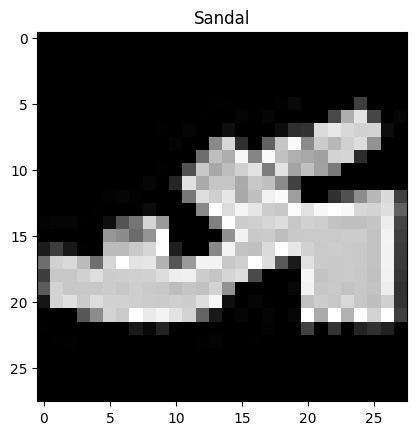

In [404]:
plt.imshow(test_samples[0].squeeze(), cmap="gray")
plt.title(class_names[test_labels[0]])

In [405]:
pred_probs = make_predictions(model = model_2,
                             data = test_samples)
pred_probs[:]

AttributeError: 'Tensor' object has no attribute 'append'